In [15]:
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

from main import TPRF

In [27]:
np.random.seed(42)

n_samples = 150
n_features = 20
n_relevant = 5

# Factor F: Drives GDP and the first 5 indicators
F = np.random.normal(0, 1, n_samples)

# Factor G: Drives the NEXT 15 indicators, but DOES NOT drive GDP
G = np.random.normal(0, 2, n_samples) # Make G even stronger than F

# Target (GDP) depends ONLY on F
y = 3 * F + np.random.normal(0, 0.5, n_samples)

X = np.zeros((n_samples, n_features))

# Relevant indicators: driven by F
for i in range(n_relevant):
    loading = np.random.uniform(-2, 2)
    X[:, i] = loading * F + np.random.normal(0, 0.3, n_samples)

# Irrelevant indicators: driven by G (They move together, but not with y!)
for i in range(n_relevant, n_features):
    loading = np.random.uniform(0.5, 1.5)
    X[:, i] = loading * G + np.random.normal(0, 0.3, n_samples)

# --- Train / Test Split ---
# Simulate a rolling-origin evaluation: train on past, test on future
train_size = 100
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# --- Test the TPRF Object ---
model = TPRF()

# Fit Step 1 on training data
model.fit(X_train, y_train)

# Extract the learned betas
learned_betas = model.betas_

# Generate the TPRF factor for train and test sets
tprf_train = model.transform(X_train)
tprf_test = model.transform(X_test)

# --- Evaluate Results ---
print("--- Step 1 Betas (Loadings) ---")
print(f"Average absolute beta for RELEVANT features (0 to 4): {np.mean(np.abs(learned_betas[:n_relevant])):.4f}")
print(f"Average absolute beta for IRRELEVANT features (5 to 19): {np.mean(np.abs(learned_betas[n_relevant:])):.4f}")

print("\n--- Factor Effectiveness ---")
# Correlation between TPRF factor and actual GDP
corr_train = np.corrcoef(tprf_train, y_train)[0, 1]
corr_test = np.corrcoef(tprf_test, y_test)[0, 1]

print(f"Correlation(TPRF, GDP) on Training Set: {corr_train:.4f}")
print(f"Correlation(TPRF, GDP) on Test Set:     {corr_test:.4f}")

# Compare to a naive PCA approach (first principal component of X)
from sklearn.decomposition import PCA
pca = PCA(n_components=1)
pca_train = pca.fit_transform(StandardScaler().fit_transform(X_train)).flatten()
corr_pca_train = np.corrcoef(pca_train, y_train)[0, 1]

pca_test = pca.transform(StandardScaler().fit(X_train).transform(X_test)).flatten()
corr_pca_test = np.corrcoef(pca_test, y_test)[0, 1]

print(f"\nCorrelation(PCA_1, GDP) on Training Set: {corr_pca_train:.4f}")
print(f"Correlation(PCA_1, GDP) on Test Set:     {corr_pca_test:.4f}")

--- Step 1 Betas (Loadings) ---
Average absolute beta for RELEVANT features (0 to 4): 0.9479
Average absolute beta for IRRELEVANT features (5 to 19): 0.0254

--- Factor Effectiveness ---
Correlation(TPRF, GDP) on Training Set: 0.8841
Correlation(TPRF, GDP) on Test Set:     0.8881

Correlation(PCA_1, GDP) on Training Set: -0.0435
Correlation(PCA_1, GDP) on Test Set:     -0.0159


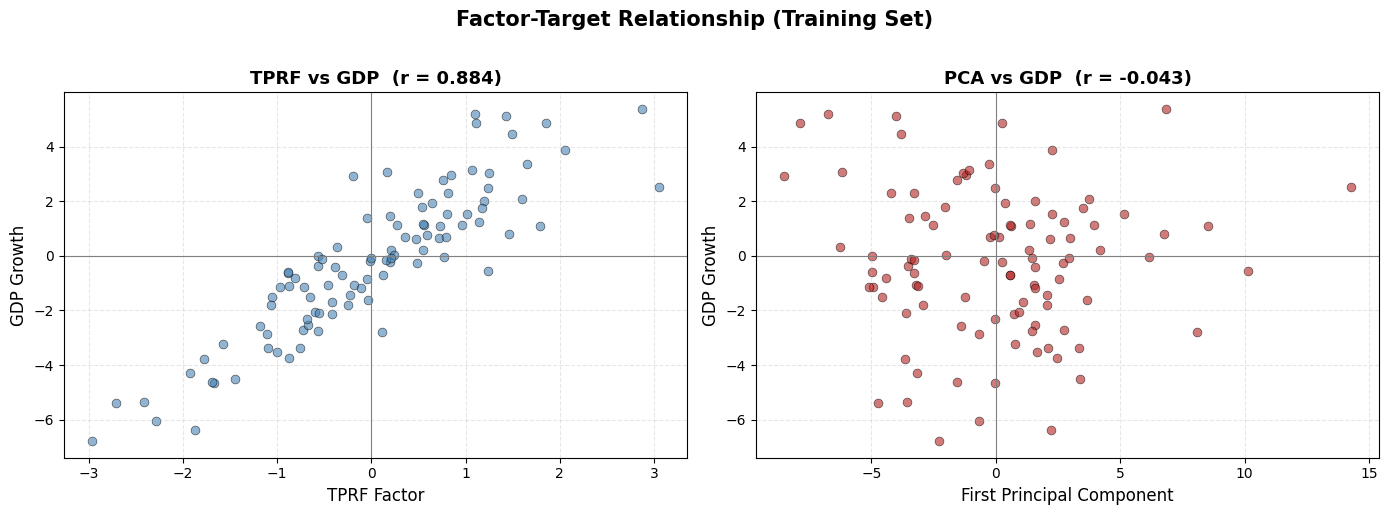

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- TPRF Scatter ---
axes[0].scatter(tprf_train, y_train, alpha=0.6, edgecolor='k', linewidth=0.5, s=40, c='steelblue')
axes[0].set_xlabel('TPRF Factor', fontsize=12)
axes[0].set_ylabel('GDP Growth', fontsize=12)
axes[0].set_title(f'TPRF vs GDP  (r = {corr_train:.3f})', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].axhline(y=0, color='grey', linewidth=0.8, linestyle='-')
axes[0].axvline(x=0, color='grey', linewidth=0.8, linestyle='-')

# --- PCA Scatter ---
axes[1].scatter(pca_train, y_train, alpha=0.6, edgecolor='k', linewidth=0.5, s=40, c='firebrick')
axes[1].set_xlabel('First Principal Component', fontsize=12)
axes[1].set_ylabel('GDP Growth', fontsize=12)
axes[1].set_title(f'PCA vs GDP  (r = {corr_pca_train:.3f})', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].axhline(y=0, color='grey', linewidth=0.8, linestyle='-')
axes[1].axvline(x=0, color='grey', linewidth=0.8, linestyle='-')

fig.suptitle('Factor-Target Relationship (Training Set)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()